In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [8]:
df = pd.read_csv('insurance.csv')
print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [12]:
# Perform Exploratory Data Analysis (EDA)
print(" 1. Summary Statistics for Numerical Columns")
print(df.describe())

print("\n 2. Checking for Missing Values")
print(df.isnull().sum())

print("\n 3. Distribution Counts for Categorical Columns")
if 'sex' in df.columns:
    print(df['sex'].value_counts())
if 'smoker' in df.columns:
    print(df['smoker'].value_counts())
if 'region' in df.columns:
    print(df['region'].value_counts())

 1. Summary Statistics for Numerical Columns
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

 2. Checking for Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 3. Distribution Counts for Categorical Columns
sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


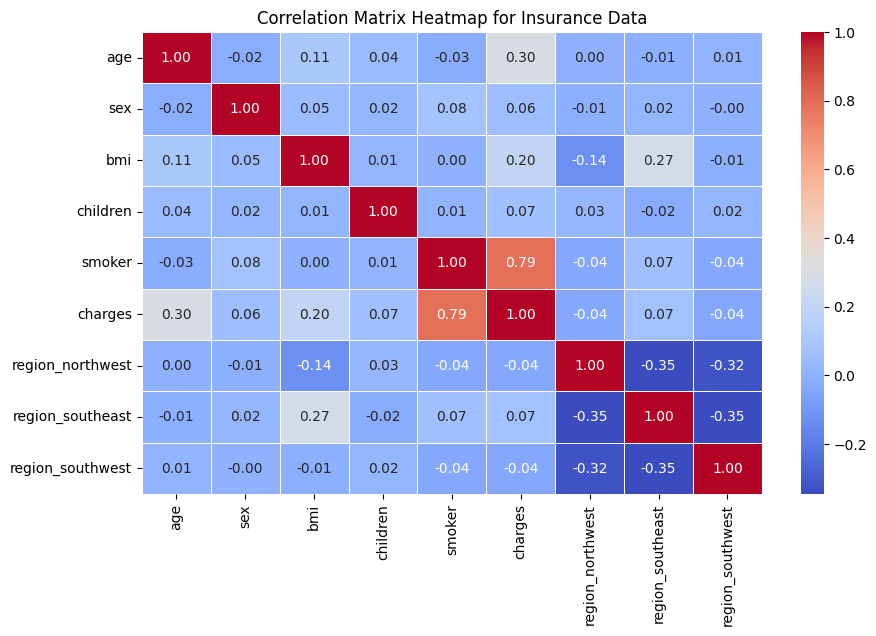

In [28]:
#heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Calculate the correlation matrix for all numerical columns
correlation_matrix = df.corr()

# Plot the heatmap with values drawn inside the squares
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap for Insurance Data')
plt.show()

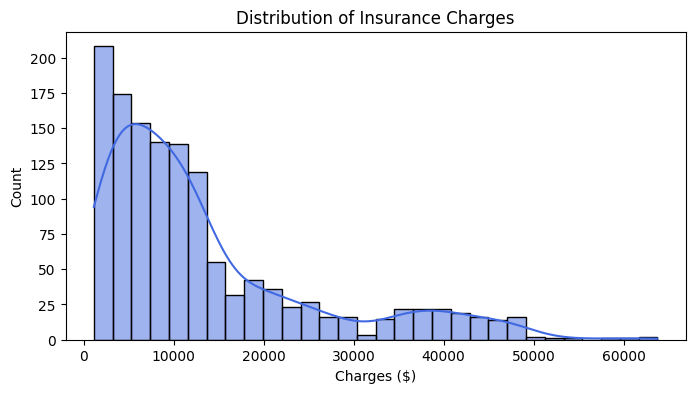

In [14]:
# Visualize the data using scatter plots and histograms. 
# Distribution of Target Variable (Histogram)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.show()

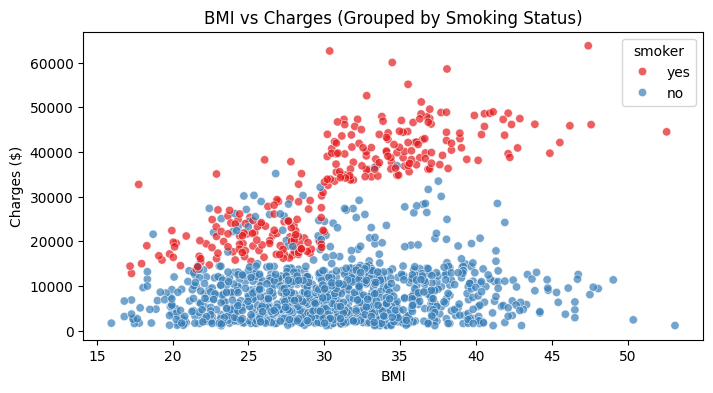

In [16]:
# Relationship Between Features (Scatter Plot)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('BMI vs Charges (Grouped by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.show()


In [17]:
# Cleaning and preprocessing the dataset

df = df.drop_duplicates().dropna()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# 1. Label Encoding for binary categories (two choices)
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

# 2. One-Hot Encoding for multi-class categories (Avoids the Dummy Variable Trap)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("Preprocessed Dataset Sample:")
print(df.head())


Preprocessed Dataset Sample:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [19]:
# Train a Linear Regression or Multiple Linear Regression model.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Feature Selection
X = df.drop(columns=['charges'])
y = df['charges']

# 2. Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model training complete using {X_train.shape[0]} samples!")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficients map: {dict(zip(X.columns, model.coef_))}")

Model training complete using 1069 samples!
Intercept: -11092.65
Coefficients map: {'age': np.float64(248.21072022470474), 'sex': np.float64(-101.54205399029787), 'bmi': np.float64(318.70144095235025), 'children': np.float64(533.009988798697), 'smoker': np.float64(23077.764592868127), 'region_northwest': np.float64(-391.7614547836105), 'region_southeast': np.float64(-838.91961572696), 'region_southwest': np.float64(-659.1397515529715)}


In [24]:
# Testing the model with new input data.

import pandas as pd

# Define a completely new person's details

new_customer = pd.DataFrame({
    'age': [28],
    'sex': [1],          # 1 for Male, 0 for Female
    'bmi': [26.5],       # Healthy weight range
    'children': [0],     # No dependants
    'smoker': [0],       # 0 for Non-Smoker, 1 for Smoker
    'region_northwest': [False],
    'region_southeast': [True],
    'region_southwest': [False]
})

# Run the prediction
predicted_cost = model.predict(new_customer)
print(f"Predicted Insurance Cost for the new customer: ${predicted_cost[0]:.2f}")

Predicted Insurance Cost for the new customer: $3362.37


In [25]:
df.describe()

,age,sex,bmi,children,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [26]:
# Evaluating the accuracy and save the trained model for future use 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

y_pred = model.predict(X_test)

# 2. Compute performance tracking metrics
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 Score (Model Accuracy): {r2_score(y_test, y_pred):.4f}\n")

# 3. Serialize and save the trained regression model to a local file
joblib.dump(model, 'insurance_prediction_model.pkl')
print("Trained model saved successfully as 'insurance_prediction_model.pkl'!")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): $4177.05
Root Mean Squared Error (RMSE): $5956.34
R2 Score (Model Accuracy): 0.8069

Trained model saved successfully as 'insurance_prediction_model.pkl'!
